<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Cwiczenie_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

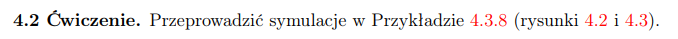

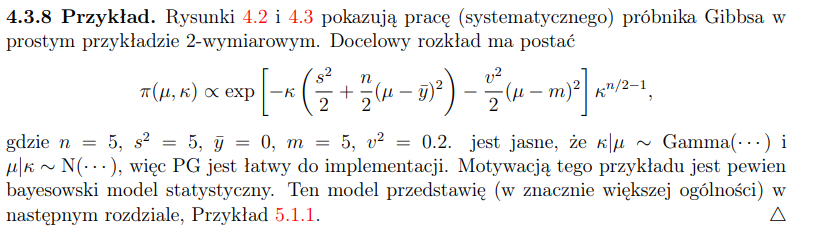

## Conditional distributions
---

Before proceeding with the simulation, we must derive the formulas for conditional distributions. Let us recall our joint distribution:

$$ \pi(\mu, \kappa) \propto \exp \left[ -\kappa \left( \frac{s^2}{2} + \frac{n}{2}(\mu - \bar{y})^2 \right) - \frac{v^2}{2}(\mu - m)^2 \right] \kappa^{n/2 - 1}, $$

where $n = 5$, $s^2 = 5$, $\bar{y} = 0$, $m = 5$, $v^2 = 0.2$. Therefore, it transforms to:

$$ \pi(\mu, \kappa) \propto \exp \left[ -\kappa \left( 2.5 + 2.5 \mu^2 \right) - 0.1 (\mu - 5)^2 \right] \kappa^{1.5} $$

To obtain the conditional distribution of $\kappa | \mu$, we must get rid of all terms in above formula, which don't contain $\kappa$. As a result, we obtain:

$$ \pi(\kappa | \mu) \propto \kappa^{1.5} \exp \left[ -\kappa \left( 2.5 + 2.5 \mu^2 \right) \right], $$

what corresponds to distribution $Γ(2.5, 2.5 + 2.5\mu^2)$

Analogously, we can acquire the remaining conditional distribution $\mu | \kappa$:

$$ \pi(\mu | \kappa) \propto \exp \left[ -2.5 \kappa \mu^2 - 0.1 (\mu^2 - 10\mu + 25) \right] $$$$ \propto \exp \left[ -\mu^2(2.5 \kappa + 0.1) + \mu - 2.5 \right] $$$$ \propto \exp \left[ -\frac{1}{2} \left( \mu^2(5 \kappa + 0.2) - 2\mu \right) \right] $$,

which corresponds to distribution $\mathcal{N}\left(\frac{1}{5\kappa + 0.2}, \frac{1}{5\kappa + 0.2}\right)$.



## Simulations
---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# setup
num_samples = 5000

# how much starting samples we will delete
burn_in = 500

In [4]:
# arrays for storing results
mu_samples = np.zeros(num_samples)
kappa_samples = np.zeros(num_samples)

# initialization
mu_current = 0.0
kappa_current = 1.0

In [5]:
# Gibbs sampling
for i in range(num_samples):
    # sampling from conditional distribution `kappa | mu`
    alpha = 2.5
    beta = 2.5 * (1 + mu_current**2)
    kappa_current = np.random.gamma(shape=alpha, scale=1.0/beta)

    # sampling from conditional distribution `mu | kappa`
    mean_mu = 1.0 / (5.0 * kappa_current + 0.2)
    var_mu = 1.0 / (5.0 * kappa_current + 0.2)
    std_mu = np.sqrt(var_mu)
    mu_current = np.random.normal(loc=mean_mu, scale=std_mu)

    # saving results
    mu_samples[i] = mu_current
    kappa_samples[i] = kappa_current

# deleting burn-in
mu_final = mu_samples[burn_in:]
kappa_final = kappa_samples[burn_in:]

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\k'
<>:17: SyntaxWarning: invalid escape sequence '\k'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\k'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\k'
<>:17: SyntaxWarning: invalid escape sequence '\k'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_650/791062541.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$\mu$ trajectory')
/tmp/ipykernel_650/791062541.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$\mu$')
/tmp/ipykernel_650/791062541.py:15: SyntaxWarning: invalid escape s

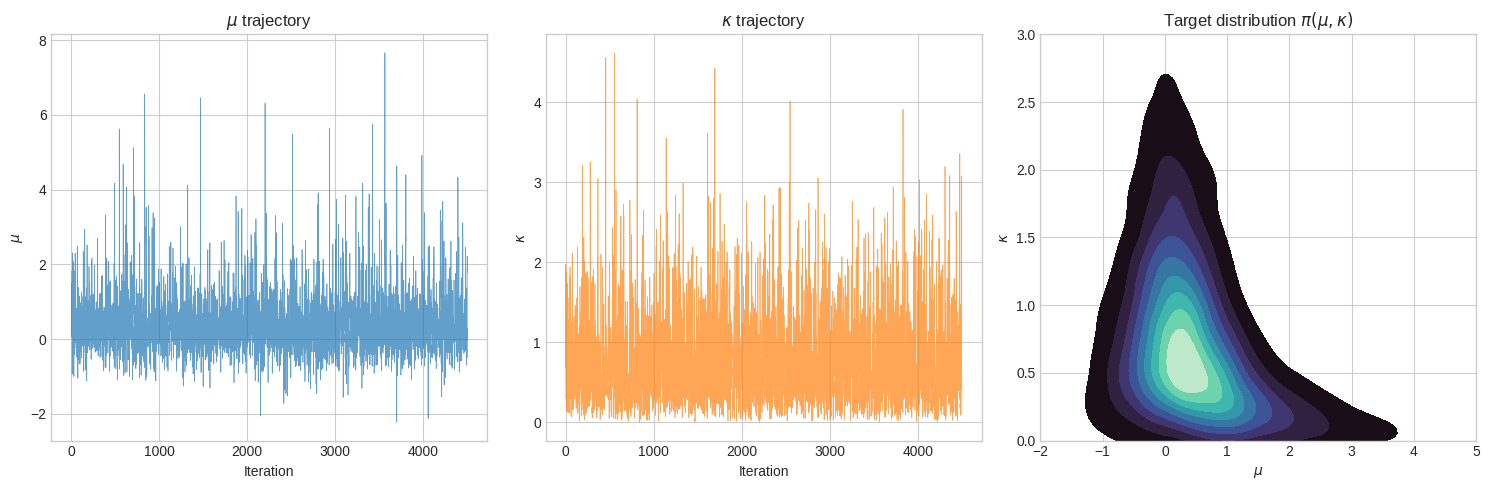

In [7]:
# visualization
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 5))

# Plot 1: mu trajectory
ax1 = plt.subplot(1, 3, 1)
ax1.plot(mu_final, alpha=0.7, color='#1f77b4', linewidth=0.5)
ax1.set_title('$\mu$ trajectory')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('$\mu$')

# Plot 2: kappa trajectory
ax2 = plt.subplot(1, 3, 2)
ax2.plot(kappa_final, alpha=0.7, color='#ff7f0e', linewidth=0.5)
ax2.set_title('$\kappa$ trajectory')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('$\kappa$')

# Plot 3: Target distribution
ax3 = plt.subplot(1, 3, 3)
# density map - kde
sns.kdeplot(x=mu_final, y=kappa_final, cmap="mako", fill=True, ax=ax3)
ax3.set_title('Target distribution $\pi(\mu, \kappa)$')
ax3.set_xlabel('$\mu$')
ax3.set_ylabel('$\kappa$')
ax3.set_xlim(-2, 5)
ax3.set_ylim(0, 3)

plt.tight_layout()
plt.show()